# Pfynwald HyPlant Co-registration Workflow

This notebook performs **geometric co-registration of HyPlant imagery to a UAV reference image** using the **AROSICS** package (Scheffler et al., 2017).

For each HyPlant image, a structural gradient proxy is generated from a product-specific matching band and compared with a **1 m UAV structural-gradient reference**. AROSICS `COREG_LOCAL` estimates a spatially distributed set of local tie-point shifts across the study area.

The workflow then:

1. Filters tie points using the AROSICS SSIM/RANSAC filters and an additional **translation-consistency filter**.
2. Derives a single robust **global x/y translation** from the median of the remaining tie-point shifts.
3. Applies this translation to the native HyPlant raster by updating its geotransform only, i.e. **without resampling the original pixel values**.
4. Crops and masks the shifted raster to the defined study area.
5. Resamples the co-registered raster **once** onto a common shared grid for consistent pixel alignment between acquisitions.
6. Generates QC statistics and visual diagnostics to assess tie-point consistency and registration quality.

Outputs are organized into separate directories for:

- `native_grid/` — co-registered rasters on their native pixel grid, without interpolation
- `shared_grid/` — co-registered rasters resampled to the common analysis grid
- `registration_proxies/` — structural-gradient images used for matching
- `qc/` — tie-point tables, registration summaries and diagnostic results

UAV reference products and the shared-grid template are stored separately under the co-registration base directory.


#### Installation Notes — AROSICS on Windows

Installing **AROSICS** on Windows can be tricky due to dependencies like **GDAL**.  
Here’s the setup process that worked reliably for me:

```bash
# Create a new conda environment (Python 3.11)
conda create -c conda-forge --name arosics python=3.11
conda activate arosics

# Install GDAL first (this is often the main issue on Windows)
pip install gdal-installer
gdal-installer  # command-line setup for GDAL binaries

# Install required dependencies individually
pip install cartopy geopandas joblib matplotlib numpy pandas pyproj scikit-image shapely

# Finally, install AROSICS itself
pip install arosics
```

**Note:**  
The recommended installation via conda:

```bash
conda install -c conda-forge 'arosics>=1.3.0'
```

did **not** work for me due to the failing installation of GDAL.  


For further information, troubleshooting, and documentation, see: [AROSICS Official Documentation](https://danschef.git-pages.gfz-potsdam.de/arosics/doc/index.html)

In [47]:
from pathlib import Path
import logging
import re

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import rasterio
from affine import Affine
from arosics import COREG_LOCAL
from rasterio.errors import WindowError
from rasterio.features import geometry_mask
from rasterio.plot import show
from rasterio.warp import Resampling, calculate_default_transform, reproject, transform_bounds
from rasterio.windows import Window, from_bounds, transform as window_transform
from scipy.ndimage import binary_erosion, gaussian_filter, sobel

logging.basicConfig(level=logging.INFO, format='[%(levelname)s] %(message)s')
logger = logging.getLogger(__name__)

In [ ]:
# --- Configuration ---

BASE_SHIFT_DIR = Path(r"E:/Proj1_Pfynwald_Data/HyPlant/original")
COREG_DIR_BASE = Path(r"E:/Proj1_Pfynwald_Data/HyPlant/coregistration")

UAV_IMAGE_PATH = Path(
    r"E:/Proj1_Pfynwald_Data/Drone_Data/PfynwaldCompressed/"
    r"20240823_Pfynwald_rgb_ortho_1cm_dem5cm.tif"
)

STUDY_AREA_PATH = Path(
    r"E:/Proj1_Pfynwald_Data/General/studyarea.gpkg"
)


# ------------------------------------------------------------
# Products to process
# ------------------------------------------------------------

FOLDERS = [
    # "SIF_iFLD",
    # "SIF_SFM",
    # "SIF_SFMNN",
    # "TOC_REFL",
    "VI",
    # "TASI",
]

RASTER_EXTENSIONS = {".dat", ".bsq", ".bil"}


# ------------------------------------------------------------
# Product-specific configuration
# ------------------------------------------------------------

PRODUCT_CONFIG = {
    "TOC_REFL": {
        "nodata": -999,
        "match_band": None,
        "match_wavelength_nm": 737.0,
        "uav_proxy": "exg",
    },
    "SIF_SFM": {
        "nodata": -999,
        "match_band": 2,
        "match_wavelength_nm": None,
        "uav_proxy": "exg",
    },
    "SIF_SFMNN": {
        "nodata": -999,
        "match_band": 11,
        "match_wavelength_nm": None,
        "uav_proxy": "exg",
    },
    "SIF_iFLD": {
        "nodata": -999,
        "match_band": 3,
        "match_wavelength_nm": None,
        "uav_proxy": "exg",
    },
    "VI": {
        "nodata": -999,
        "match_band": 2,
        "match_wavelength_nm": None,
        "uav_proxy": "exg",
    },
    "TASI": {
        "nodata": 0,
        "match_band": 1,
        "match_wavelength_nm": None,
        "uav_proxy": "gray",
    },
}


# ------------------------------------------------------------
# UAV proxy settings
# ------------------------------------------------------------

UAV_NODATA = 255
UAV_PROXY_CRS = "EPSG:32632"
UAV_PROXY_RES = 1.0

PROXY_NODATA = -9999.0
PROXY_SMOOTHING_SIGMA = 1.0
REBUILD_UAV_PROXIES = False


# ------------------------------------------------------------
# AROSICS settings
# ------------------------------------------------------------

COREG_WINDOW_SIZE = (64, 64)
COREG_MAX_SHIFT = 10
COREG_MAX_ITER = 5

LOCAL_GRID_RES = 8
LOCAL_MAX_POINTS = None

MIN_RELIABILITY = 0
MIN_TIEPOINTS = 10


# ------------------------------------------------------------
# QC settings
# ------------------------------------------------------------

QC_OK_MIN_TIEPOINTS = 15
QC_OK_MIN_RELIABILITY = 25
QC_OK_MAX_DEVIATION_M = 1.5


# ------------------------------------------------------------
# Shared-grid settings
# ------------------------------------------------------------

SHARED_GRID_CRS = "EPSG:32632"
SHARED_GRID_RES = 2.0
SHARED_GRID_RESAMPLING = "lanczos"


# ------------------------------------------------------------
# Product-independent output paths
# ------------------------------------------------------------

UAV_REFERENCE_DIR = COREG_DIR_BASE / "_uav_reference"
SHARED_GRID_DIR_BASE = COREG_DIR_BASE / "_shared_grid"

proxy_tag = f"{UAV_PROXY_RES:g}m_s{PROXY_SMOOTHING_SIGMA:g}"

UAV_PROXY_PATHS = {
    "exg": UAV_REFERENCE_DIR / f"UAV_ExG_gradient_{proxy_tag}.tif",
    "gray": UAV_REFERENCE_DIR / f"UAV_gray_gradient_{proxy_tag}.tif",
}

SHARED_GRID_TEMPLATE_PATH = (
    SHARED_GRID_DIR_BASE
    / f"shared_grid_{SHARED_GRID_RES:g}m_EPSG32632.tif"
)

In [49]:
# --- Generic helpers ---

def _clean_tags(tags):
    return {k: v for k, v in tags.items() if not k.upper().startswith("STATISTICS_")}


def copy_metadata(src, dst):
    for i, description in enumerate(src.descriptions or (), start=1):
        if i <= dst.count and description:
            dst.set_band_description(i, description)
        if i <= dst.count:
            tags = _clean_tags(src.tags(i))
            if tags:
                dst.update_tags(i, **tags)

    for ns in (None, "ENVI"):
        tags = _clean_tags(src.tags() if ns is None else src.tags(ns=ns))
        if tags:
            if ns is None:
                dst.update_tags(**tags)
            else:
                dst.update_tags(ns=ns, **tags)

    try:
        dst.scales = src.scales
        dst.offsets = src.offsets
    except Exception:
        pass

    for i, unit in enumerate(src.units or (), start=1):
        if i <= dst.count and unit:
            try:
                dst.set_band_unit(i, unit)
            except Exception:
                pass


def assert_north_up(src):
    if not np.isclose(src.transform.b, 0) or not np.isclose(src.transform.d, 0):
        raise ValueError(f"Rotated raster grid is not supported without resampling: {src.name}")


def load_aoi_geometry(path, crs):
    aoi = gpd.read_file(path)
    if aoi.crs is None or crs is None:
        raise ValueError(f"Missing CRS for AOI or raster: {path}")
    if aoi.crs != crs:
        aoi = aoi.to_crs(crs)
    if aoi.empty:
        raise ValueError(f"Empty AOI: {path}")
    return aoi.geometry.union_all()


def make_gradient_proxy(arr, valid, sigma=1.0):
    arr = np.asarray(arr, dtype="float32")
    valid = np.asarray(valid, dtype=bool) & np.isfinite(arr)
    if not valid.any():
        raise ValueError("No valid pixels for proxy creation.")

    p02, p98 = np.percentile(arr[valid], [2, 98])
    if p98 <= p02:
        raise ValueError("Insufficient image contrast for proxy creation.")

    norm = np.clip((arr - p02) / (p98 - p02), 0, 1)
    work = np.where(valid, norm, np.median(norm[valid]))
    smooth = gaussian_filter(work, sigma=sigma)
    grad = np.hypot(sobel(smooth, axis=1, mode="nearest"), sobel(smooth, axis=0, mode="nearest"))
    grad[~binary_erosion(valid, iterations=2, border_value=0)] = np.nan

    good = np.isfinite(grad)
    if good.any():
        g02, g98 = np.percentile(grad[good], [2, 98])
        if g98 > g02:
            grad[good] = np.clip((grad[good] - g02) / (g98 - g02), 0, 1)
    return grad.astype("float32")


def _numbers(text):
    return [float(x) for x in re.findall(r"[-+]?(?:\d*\.\d+|\d+\.?)(?:[eE][-+]?\d+)?", str(text))]


def select_match_band(src, product):
    if product["match_band"] is not None:
        band = int(product["match_band"])
        if not 1 <= band <= src.count:
            raise ValueError(f"Match band {band} outside 1..{src.count}: {src.name}")
        return band

    target = product["match_wavelength_nm"]
    envi = {k.lower().replace(" ", "_"): v for k, v in src.tags(ns="ENVI").items()}
    wavelengths = _numbers(envi.get("wavelength", ""))

    if len(wavelengths) == src.count:
        units = envi.get("wavelength_units", "").lower()
        if "micro" in units or (not units and np.nanmedian(wavelengths) < 10):
            wavelengths = [w * 1000 for w in wavelengths]
        return int(np.argmin(np.abs(np.asarray(wavelengths) - target))) + 1

    candidates = []
    for i, description in enumerate(src.descriptions or (), start=1):
        vals = [x for x in _numbers(description) if 300 <= x <= 2500]
        if vals:
            candidates.append((abs(vals[-1] - target), i))
    if candidates:
        return min(candidates)[1]

    raise ValueError(
        f"Cannot identify the band nearest {target:g} nm in {src.name}. "
        "Set match_band explicitly in PRODUCT_CONFIG."
    )


def write_proxy(path, array, crs, transform, description):
    path.parent.mkdir(parents=True, exist_ok=True)
    data = np.where(np.isfinite(array), array, PROXY_NODATA).astype("float32")
    profile = dict(
        driver="GTiff", height=data.shape[0], width=data.shape[1], count=1,
        dtype="float32", crs=crs, transform=transform, nodata=PROXY_NODATA,
        compress="LZW", BIGTIFF="IF_SAFER",
    )
    with rasterio.open(path, "w", **profile) as dst:
        dst.write(data, 1)
        dst.set_band_description(1, description)

✓ Reusing existing UAV reference products
✓ Reusing existing shared grid
UAV reference: E:\Proj1_Pfynwald_Data\HyPlant\coregistration\_uav_reference\UAV_ExG_gradient_1m_s1.tif | EPSG:32632 | (1.0, 1.0)
Shared grid:   436 × 310 | EPSG:32632 | (2.0, 2.0)


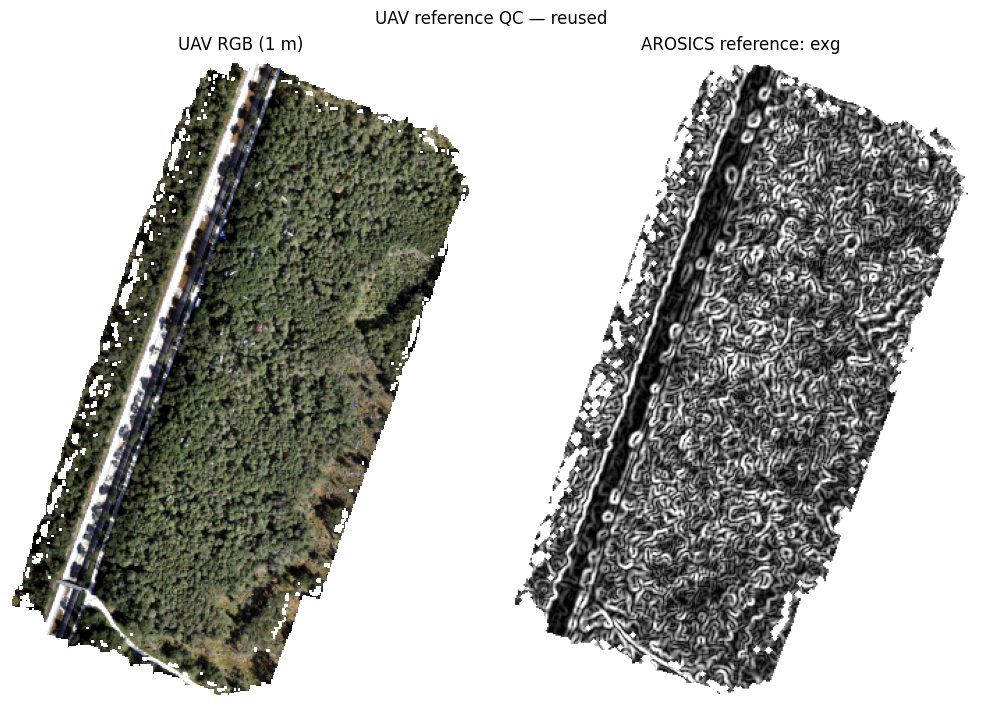

In [ ]:
# --- UAV reference products and fixed shared grid ---

UAV_RGB_REFERENCE_PATH = UAV_REFERENCE_DIR / f"UAV_RGB_{UAV_PROXY_RES:g}m.tif"


def grid_matches(path, crs, transform, width, height, count=1):
    if not path.exists():
        return False
    try:
        with rasterio.open(path) as src:
            return (
                src.crs == rasterio.crs.CRS.from_string(crs)
                and src.width == width
                and src.height == height
                and src.count == count
                and np.allclose(tuple(src.transform), tuple(transform))
            )
    except Exception:
        return False


def ensure_uav_reference():

    UAV_REFERENCE_DIR.mkdir(parents=True, exist_ok=True)

    # Expected 1 m UAV grid
    with rasterio.Env(GTIFF_SRS_SOURCE="EPSG"):
        with rasterio.open(UAV_IMAGE_PATH) as src:
            transform, width, height = calculate_default_transform(
                src.crs, UAV_PROXY_CRS,
                src.width, src.height, *src.bounds,
                resolution=UAV_PROXY_RES,
            )

    paths_ok = (
        grid_matches(UAV_RGB_REFERENCE_PATH, UAV_PROXY_CRS, transform, width, height, 3)
        and grid_matches(UAV_PROXY_PATHS["gray"], UAV_PROXY_CRS, transform, width, height)
        and grid_matches(UAV_PROXY_PATHS["exg"], UAV_PROXY_CRS, transform, width, height)
    )

    if paths_ok and not REBUILD_UAV_PROXIES:
        print("✓ Reusing existing UAV reference products")
        return False

    print("Building UAV reference products...")

    # Reproject UAV RGB once
    rgb = []

    with rasterio.Env(GTIFF_SRS_SOURCE="EPSG"):
        with rasterio.open(UAV_IMAGE_PATH) as src:

            if src.count < 3:
                raise ValueError("UAV image must contain RGB bands 1, 2 and 3.")

            src_nodata = src.nodata if src.nodata is not None else UAV_NODATA

            for band in (1, 2, 3):
                dst = np.full((height, width), np.nan, dtype="float32")

                reproject(
                    source=rasterio.band(src, band),
                    destination=dst,
                    src_transform=src.transform,
                    src_crs=src.crs,
                    src_nodata=src_nodata,
                    dst_transform=transform,
                    dst_crs=UAV_PROXY_CRS,
                    dst_nodata=np.nan,
                    resampling=Resampling.average,
                    num_threads=4,
                )

                rgb.append(dst)

    rgb = np.stack(rgb)
    r, g, b = rgb
    valid = np.all(np.isfinite(rgb), axis=0)

    # Save cached 1 m RGB
    rgb_out = np.where(np.isfinite(rgb), rgb, PROXY_NODATA).astype("float32")

    with rasterio.open(
        UAV_RGB_REFERENCE_PATH,
        "w",
        driver="GTiff",
        height=height,
        width=width,
        count=3,
        dtype="float32",
        crs=UAV_PROXY_CRS,
        transform=transform,
        nodata=PROXY_NODATA,
        compress="DEFLATE",
    ) as dst:
        dst.write(rgb_out)
        dst.write_mask(valid.astype("uint8") * 255)

    # Structural proxies
    gray = 0.299 * r + 0.587 * g + 0.114 * b
    exg = 2 * g - r - b

    for name, arr in {"gray": gray, "exg": exg}.items():
        write_proxy(
            UAV_PROXY_PATHS[name],
            make_gradient_proxy(arr, valid, PROXY_SMOOTHING_SIGMA),
            UAV_PROXY_CRS,
            transform,
            f"UAV {name} structural gradient",
        )

    print("✓ UAV reference products created")
    return True


def ensure_shared_grid_template():

    SHARED_GRID_DIR_BASE.mkdir(parents=True, exist_ok=True)

    # Shared grid is product-independent.
    # Use the fixed 1 m UAV RGB grid as the spatial anchor.
    with rasterio.open(UAV_RGB_REFERENCE_PATH) as ref:

        if ref.crs != rasterio.crs.CRS.from_string(SHARED_GRID_CRS):
            raise ValueError("Shared grid CRS must match UAV reference CRS.")

        minx, miny, maxx, maxy = load_aoi_geometry(
            STUDY_AREA_PATH, ref.crs
        ).bounds

        x0, y0 = ref.transform.c, ref.transform.f

    res = SHARED_GRID_RES

    left   = x0 + np.floor((minx - x0) / res) * res
    right  = x0 + np.ceil((maxx - x0) / res) * res
    bottom = y0 + np.floor((miny - y0) / res) * res
    top    = y0 + np.ceil((maxy - y0) / res) * res

    width = int(round((right - left) / res))
    height = int(round((top - bottom) / res))
    transform = rasterio.transform.from_origin(left, top, res, res)

    if grid_matches(
        SHARED_GRID_TEMPLATE_PATH,
        SHARED_GRID_CRS,
        transform,
        width,
        height,
    ):
        print("✓ Reusing existing shared grid")
        return

    with rasterio.open(
        SHARED_GRID_TEMPLATE_PATH,
        "w",
        driver="GTiff",
        height=height,
        width=width,
        count=1,
        dtype="uint8",
        crs=SHARED_GRID_CRS,
        transform=transform,
        nodata=0,
        compress="LZW",
    ) as dst:
        dst.write(np.zeros((height, width), dtype="uint8"), 1)
        dst.update_tags(role="grid_template")

    print("✓ Shared grid created")

# --- Build or reuse ---

uav_rebuilt = ensure_uav_reference()
ensure_shared_grid_template()

with rasterio.open(UAV_RGB_REFERENCE_PATH) as ref, \
     rasterio.open(SHARED_GRID_TEMPLATE_PATH) as grid:

    print(
        f"UAV reference grid: "
        f"{ref.width} × {ref.height} | {ref.crs} | {ref.res}"
    )

    print(
        f"Shared grid: "
        f"{grid.width} × {grid.height} | {grid.crs} | {grid.res}"
    )

print("Available UAV matching proxies:")
for name, path in UAV_PROXY_PATHS.items():
    print(f"  {name}: {path}")


# ============================================================
# Quick QC view — always shown
# ============================================================

# ============================================================
# Quick QC view — UAV references
# ============================================================

def stretch(arr):
    out = np.zeros_like(arr, dtype="float32")

    for i in range(arr.shape[0]):
        valid = np.isfinite(arr[i])

        if not np.any(valid):
            continue

        lo, hi = np.nanpercentile(arr[i][valid], [2, 98])

        if hi > lo:
            out[i] = np.clip(
                (arr[i] - lo) / (hi - lo),
                0,
                1,
            )

    return np.moveaxis(out, 0, -1)


# RGB
with rasterio.open(UAV_RGB_REFERENCE_PATH) as src:
    rgb = (
        src.read(masked=True)
        .astype("float32")
        .filled(np.nan)
    )

    extent = [
        src.bounds.left,
        src.bounds.right,
        src.bounds.bottom,
        src.bounds.top,
    ]


# Matching proxies
proxies = {}

for name, path in UAV_PROXY_PATHS.items():
    with rasterio.open(path) as src:
        proxies[name] = (
            src.read(1, masked=True)
            .astype("float32")
            .filled(np.nan)
        )


# Plot
fig, ax = plt.subplots(
    1,
    3,
    figsize=(15, 7),
    constrained_layout=True,
)

ax[0].imshow(
    stretch(rgb),
    extent=extent,
    origin="upper",
)
ax[0].set_title(f"UAV RGB ({UAV_PROXY_RES:g} m)")


for a, name in zip(ax[1:], ("exg", "gray")):

    proxy = proxies[name]
    valid = np.isfinite(proxy)

    vmin, vmax = np.nanpercentile(
        proxy[valid],
        [2, 98],
    )

    a.imshow(
        proxy,
        extent=extent,
        origin="upper",
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
    )

    a.set_title(f"UAV {name.upper()} gradient")


for a in ax:
    a.set_aspect("equal")
    a.axis("off")


fig.suptitle(
    f"UAV reference QC — "
    f"{'rebuilt' if uav_rebuilt else 'reused'}"
)

plt.show()

In [ ]:
# --- Inputs and output folders ---

def setup_folder(folder):
    global FOLDER, PRODUCT, INPUT_DIR, shift_images
    global OUT_DIR, NATIVE_COREG_DIR, SHARED_GRID_DIR, PROXY_DIR, QC_DIR
    global UAV_REFERENCE_PROXY_PATH

    if folder not in PRODUCT_CONFIG:
        raise ValueError(f"Unknown product: {folder}")

    # Current product
    FOLDER = folder
    PRODUCT = PRODUCT_CONFIG[folder]

    # Input
    INPUT_DIR = BASE_SHIFT_DIR / folder

    # Product-specific outputs
    OUT_DIR = COREG_DIR_BASE / folder
    NATIVE_COREG_DIR = OUT_DIR / "native_grid"
    SHARED_GRID_DIR = OUT_DIR / "shared_grid"
    PROXY_DIR = OUT_DIR / "registration_proxies"
    QC_DIR = OUT_DIR / "qc"

    # Product-specific UAV matching proxy
    UAV_REFERENCE_PROXY_PATH = UAV_PROXY_PATHS[PRODUCT["uav_proxy"]]

    if not INPUT_DIR.exists():
        raise FileNotFoundError(f"Input directory does not exist: {INPUT_DIR}")

    shift_images = sorted(
        p for p in INPUT_DIR.iterdir()
        if p.is_file() and p.suffix.lower() in RASTER_EXTENSIONS
    )

    if not shift_images:
        raise FileNotFoundError(
            f"No supported rasters found in {INPUT_DIR}"
        )

    for directory in (
        NATIVE_COREG_DIR,
        SHARED_GRID_DIR,
        PROXY_DIR,
        QC_DIR,
    ):
        directory.mkdir(parents=True, exist_ok=True)

    print(
        f"\n{'=' * 60}\n"
        f"Product:   {FOLDER}\n"
        f"Images:    {len(shift_images)}\n"
        f"Input:     {INPUT_DIR}\n"
        f"Output:    {OUT_DIR}\n"
        f"UAV proxy: {PRODUCT['uav_proxy']}\n"
        f"{'=' * 60}"
    )

In [52]:
# --- Registration helpers ---

def make_target_proxy(src_path, out_path):
    with rasterio.open(src_path) as src:
        assert_north_up(src)
        band = select_match_band(src, PRODUCT)
        arr = src.read(band).astype("float32")
        valid = src.read_masks(band) > 0
        nodata = PRODUCT["nodata"]
        if nodata is not None:
            valid &= arr != nodata
        proxy = make_gradient_proxy(arr, valid, PROXY_SMOOTHING_SIGMA)
        write_proxy(out_path, proxy, src.crs, src.transform, f"Target structural gradient; source band {band}")
    return band


def _round_window_outward(window):
    c0, r0 = np.floor([window.col_off, window.row_off]).astype(int)
    c1 = int(np.ceil(window.col_off + window.width))
    r1 = int(np.ceil(window.row_off + window.height))
    return Window(c0, r0, c1 - c0, r1 - r0)

# --- Registration ---

def estimate_global_shift(ref_path, tgt_path):
    crl = COREG_LOCAL(
        str(ref_path),
        str(tgt_path),
        grid_res=LOCAL_GRID_RES,
        max_points=LOCAL_MAX_POINTS,
        window_size=COREG_WINDOW_SIZE,
        r_b4match=1,
        s_b4match=1,
        max_iter=COREG_MAX_ITER,
        max_shift=COREG_MAX_SHIFT,
        nodata=(PROXY_NODATA, PROXY_NODATA),

        tieP_filter_level=3,
        min_reliability=MIN_RELIABILITY,
        tieP_random_state=0,
        rs_random_state=0,

        align_grids=False,
        match_gsd=False,
        resamp_alg_calc="cubic",

        binary_ws=False,
        force_quadratic_win=True,

        progress=False,
        q=True,
        ignore_errors=True,
    )

    crl.calculate_spatial_shifts()

    matches = crl.CoRegPoints_table.copy()

    if matches.empty:
        raise RuntimeError("AROSICS found no tie points.")

    # Valid numerical shifts
    valid = (
        matches["X_SHIFT_M"].notna()
        & matches["Y_SHIFT_M"].notna()
        & (matches["X_SHIFT_M"] != PROXY_NODATA)
        & (matches["Y_SHIFT_M"] != PROXY_NODATA)
    )

    # 1. Final AROSICS inliers: SSIM + RANSAC etc.
    arosics_good = valid & matches["OUTLIER"].eq(False)
    matches["arosics_inlier"] = arosics_good

    if arosics_good.sum() < MIN_TIEPOINTS:
        raise RuntimeError(
            f"Only {int(arosics_good.sum())} valid AROSICS tie points."
        )

    # 2. Robust centre of AROSICS inliers
    dx0 = matches.loc[arosics_good, "X_SHIFT_M"].median()
    dy0 = matches.loc[arosics_good, "Y_SHIFT_M"].median()

    dev0 = np.hypot(
        matches["X_SHIFT_M"] - dx0,
        matches["Y_SHIFT_M"] - dy0,
    )

    # 3. Translation-specific robust filter
    d = dev0[arosics_good]

    med_dev = d.median()
    mad_dev = np.median(np.abs(d - med_dev))

    threshold = max(
        1.5,                         # minimum tolerance [m]
        med_dev + 3 * 1.4826 * mad_dev
    )

    translation_good = arosics_good & (dev0 <= threshold)

    matches["translation_inlier"] = translation_good
    matches["used"] = translation_good

    if translation_good.sum() < MIN_TIEPOINTS:
        raise RuntimeError(
            f"Only {int(translation_good.sum())} translation-consistent tie points."
        )

    # 4. Final global translation
    dx = float(matches.loc[translation_good, "X_SHIFT_M"].median())
    dy = float(matches.loc[translation_good, "Y_SHIFT_M"].median())

    # Final deviations for QC
    matches["deviation_from_median_m"] = np.hypot(
        matches["X_SHIFT_M"] - dx,
        matches["Y_SHIFT_M"] - dy,
    )

    return dx, dy, matches

In [53]:
# --- Output helpers ---

def _gtiff_profile(src, **updates):
    profile = src.profile.copy()
    for key in ("blockxsize", "blockysize", "tiled", "interleave"):
        profile.pop(key, None)
    profile.update(driver="GTiff", compress="LZW", BIGTIFF="IF_SAFER", **updates)
    return profile


def write_native_coreg(src_path, out_path, dx, dy):
    with rasterio.open(src_path) as src:
        assert_north_up(src)
        shifted = Affine.translation(dx, dy) * src.transform
        geom = load_aoi_geometry(STUDY_AREA_PATH, src.crs)

        window = _round_window_outward(from_bounds(*geom.bounds, transform=shifted))
        try:
            window = window.intersection(Window(0, 0, src.width, src.height))
        except WindowError as exc:
            raise ValueError("Shifted raster does not overlap the study area.") from exc

        data = src.read(window=window)
        transform = window_transform(window, shifted)
        inside = geometry_mask([geom.__geo_interface__], data.shape[1:], transform, invert=True)
        nodata = PRODUCT["nodata"] if PRODUCT["nodata"] is not None else src.nodata
        if nodata is None:
            raise ValueError("A NoData value is required for the native AOI crop.")
        data[:, ~inside] = np.asarray(nodata, dtype=data.dtype)

        profile = _gtiff_profile(
            src, height=data.shape[1], width=data.shape[2], transform=transform, nodata=nodata,
        )
        with rasterio.open(out_path, "w", **profile) as dst:
            dst.write(data)
            copy_metadata(src, dst)
            dst.update_tags(coreg_reference="UAV", coreg_shift_x_map=dx, coreg_shift_y_map=dy,
                            coreg_resampled="false")


def resample_to_shared_grid(src_path, out_path):
    resampling = getattr(Resampling, SHARED_GRID_RESAMPLING)
    with rasterio.open(src_path) as src, rasterio.open(SHARED_GRID_TEMPLATE_PATH) as grid:
        profile = _gtiff_profile(
            src, height=grid.height, width=grid.width, crs=grid.crs,
            transform=grid.transform, nodata=src.nodata,
        )
        with rasterio.open(out_path, "w", **profile) as dst:
            for band in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, band), destination=rasterio.band(dst, band),
                    src_transform=src.transform, src_crs=src.crs, src_nodata=src.nodata,
                    dst_transform=grid.transform, dst_crs=grid.crs, dst_nodata=src.nodata,
                    resampling=resampling, num_threads=4,
                )
            copy_metadata(src, dst)
            dst.update_tags(coreg_resampled="true", shared_grid=str(SHARED_GRID_TEMPLATE_PATH),
                            shared_grid_resampling=SHARED_GRID_RESAMPLING)

In [54]:
# --- Run batch for all products ---

def process_folder():

    summary_rows = []
    match_tables = []

    for i, src_path in enumerate(shift_images, start=1):
        logger.info("[%s | %d/%d] %s", FOLDER, i, len(shift_images), src_path.name)

        proxy_path = PROXY_DIR / f"{src_path.stem}_gradient.tif"
        native_path = NATIVE_COREG_DIR / f"{src_path.stem}_coreg_native.tif"
        shared_path = SHARED_GRID_DIR / f"{src_path.stem}_coreg_shared.tif"

        try:
            # Registration
            band = make_target_proxy(src_path, proxy_path)

            dx, dy, matches = estimate_global_shift(
                UAV_REFERENCE_PROXY_PATH,
                proxy_path,
            )

            matches.insert(0, "image", src_path.name)
            match_tables.append(matches)

            # Outputs
            write_native_coreg(src_path, native_path, dx, dy)
            resample_to_shared_grid(native_path, shared_path)

            # QC
            aro = matches["arosics_inlier"]
            used = matches["translation_inlier"]

            n_arosics = int(aro.sum())
            n_matches = int(used.sum())
            retained_pct = 100 * n_matches / n_arosics if n_arosics else 0

            dev = matches.loc[used, "deviation_from_median_m"]
            median_dev = float(dev.median())
            p90_dev = float(dev.quantile(0.90))

            if n_matches < 15 or retained_pct < 50:
                status = "POOR"
            elif retained_pct >= 70 and median_dev <= 1.0 and p90_dev <= 2.0:
                status = "GOOD"
            else:
                status = "REVIEW"

            summary_rows.append(dict(
                image=src_path.name,
                status=status,
                match_band=band,
                x_shift_map=dx,
                y_shift_map=dy,
                shift_m=np.hypot(dx, dy),
                n_arosics=n_arosics,
                n_matches=n_matches,
                retained_pct=retained_pct,
                median_dev_m=median_dev,
                p90_dev_m=p90_dev,
                native_output=str(native_path),
                shared_output=str(shared_path),
                error=None,
            ))

        except Exception as exc:
            logger.error("Failed %s: %s", src_path.name, exc)

            summary_rows.append(dict(
                image=src_path.name,
                status="FAILED",
                error=str(exc),
            ))

    summary_df = pd.DataFrame(summary_rows)
    match_df = (
        pd.concat(match_tables, ignore_index=True)
        if match_tables else pd.DataFrame()
    )

    summary_df.to_csv(QC_DIR / "coreg_summary.csv", index=False)
    match_df.to_csv(QC_DIR / "coreg_matches.csv", index=False)

    return summary_df, match_df


# ------------------------------------------------------------
# Run selected folders
# ------------------------------------------------------------

all_summaries = []
all_matches = {}

for folder in FOLDERS:

    setup_folder(folder)

    summary_df, match_df = process_folder()

    summary_df.insert(0, "product", folder)

    all_summaries.append(summary_df)
    all_matches[folder] = match_df

    print(
        f"✓ {folder}: "
        f"{(summary_df['status'] != 'FAILED').sum()}/{len(summary_df)} processed"
    )


# ------------------------------------------------------------
# Combined overview
# ------------------------------------------------------------

all_summary_df = pd.concat(all_summaries, ignore_index=True)

display(
    all_summary_df[
        [
            "product",
            "image",
            "status",
            "shift_m",
            "n_matches",
            "retained_pct",
            "median_dev_m",
            "p90_dev_m",
        ]
    ].round(2)
)

[INFO] [VI | 1/18] 20230617-PHY-1117-1360-L1-E-DUAL-rect_img_atm_pol_indices_up.bsq



Product:   VI
Images:    18
UAV proxy: exg


c:\Users\avinn\anaconda3\envs\arosics\Lib\site-packages\arosics\CoReg.py:123: UserWarning: The footprint of the reference image contains multiple separate image parts. AROSICS will only process the largest image part.
  warnings.warn(f'The footprint of the {self.imName} contains multiple separate image parts. '


Calculating tie point grid (328 points) using 16 CPU cores...


[INFO] [VI | 2/18] 20230617-PHY-1124-1360-L2-W-DUAL-rect_img_atm_pol_indices_up.bsq
c:\Users\avinn\anaconda3\envs\arosics\Lib\site-packages\arosics\CoReg.py:123: UserWarning: The footprint of the reference image contains multiple separate image parts. AROSICS will only process the largest image part.
  warnings.warn(f'The footprint of the {self.imName} contains multiple separate image parts. '


...

[INFO] [VI | 17/18] 20260805-PHY-1020-1340-L2-W-DUAL_radiance_img_atm_pol_indices_up-rect.bsq
c:\Users\avinn\anaconda3\envs\arosics\Lib\site-packages\arosics\CoReg.py:123: UserWarning: The footprint of the reference image contains multiple separate image parts. AROSICS will only process the largest image part.
  warnings.warn(f'The footprint of the {self.imName} contains multiple separate image parts. '


Calculating tie point grid (326 points) using 16 CPU cores...


[INFO] [VI | 18/18] 20260805-PHY-1026-1340-L1-E-DUAL_radiance_img_atm_pol_indices_up-rect.bsq
c:\Users\avinn\anaconda3\envs\arosics\Lib\site-packages\arosics\CoReg.py:123: UserWarning: The footprint of the reference image contains multiple separate image parts. AROSICS will only process the largest image part.
  warnings.warn(f'The footprint of the {self.imName} contains multiple separate image parts. '


Calculating tie point grid (321 points) using 16 CPU cores...
✓ VI: 16/18 processed


,product,image,status,shift_m,n_matches,retained_pct,median_dev_m,p90_dev_m
0,VI,20230617-PHY-1117-1360-L1-E-DUAL-rect_img_atm_...,POOR,0.51,11.0,64.71,1.00,1.12
1,VI,20230617-PHY-1124-1360-L2-W-DUAL-rect_img_atm_...,POOR,0.78,13.0,72.22,1.38,12.25
2,VI,20240613-PHY-1143-1340-L1-W-DUAL_radiance_img_...,POOR,0.88,13.0,81.25,1.41,4.85
3,VI,20240613-PHY-1149-1340-L2-W-DUAL_radiance_img_...,FAILED,NaN,NaN,NaN,NaN,NaN
4,VI,20240613-PHY-1154-1340-L2-E-DUAL_radiance_img_...,REVIEW,9.48,28.0,100.00,9.27,27.17
5,VI,20240613-PHY-1200-1340-L1-E-DUAL_radiance_img_...,REVIEW,9.38,21.0,95.45,9.42,14.46
6,VI,20240823-PHY-1248-1340-L1-E-DUAL_radiance_img_...,GOOD,0.88,32.0,96.97,0.61,1.66
7,VI,20240823-PHY-1253-1340-L2-E-DUAL_radiance_img_...,GOOD,1.08,21.0,100.00,0.99,1.96
8,VI,20240823-PHY-1259-1340-L2-W-DUAL_radiance_img_...,GOOD,0.65,38.0,92.68,0.47,1.13
9,VI,20240823-PHY-1305-1340-L1-W-DUAL_radiance_img_...,GOOD,0.81,44.0,83.02,0.58,0.90


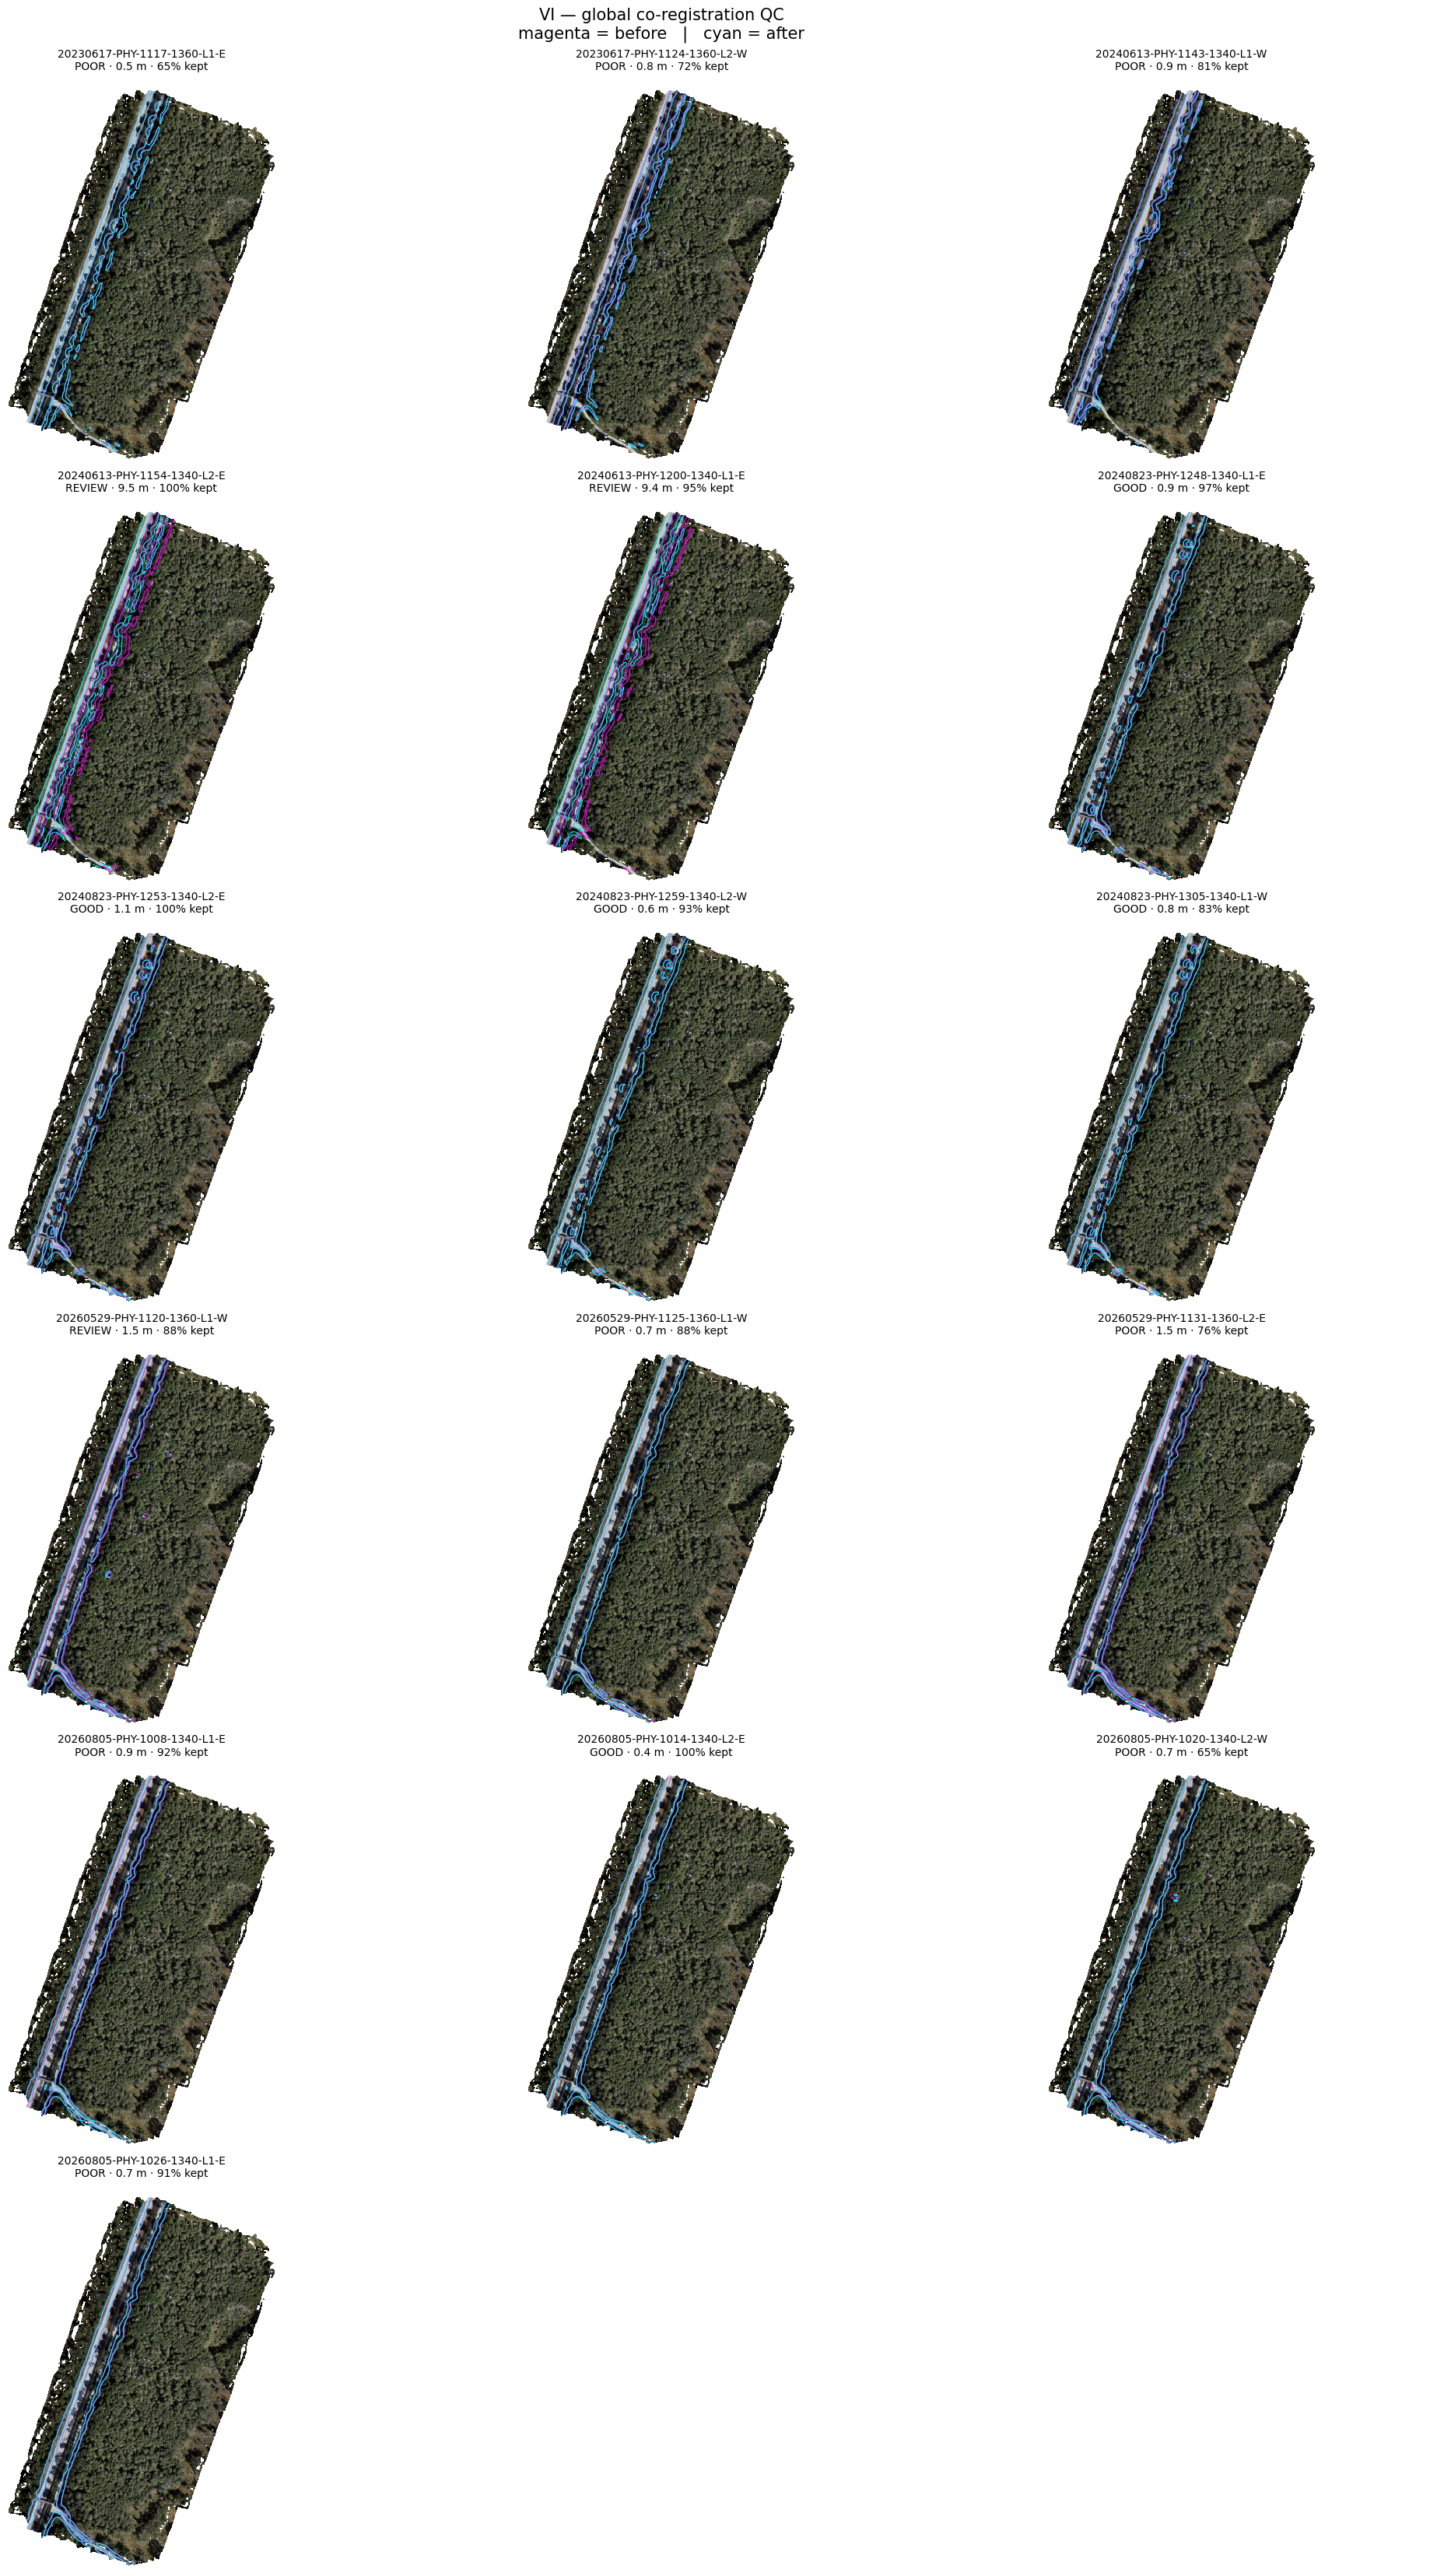

In [55]:
# --- Co-registration diagnostics for all products ---

EDGE_PERCENTILE = 94
EDGE_LINEWIDTH = 0.8
NCOLS = 3


def stretch_rgb(rgb):
    out = np.zeros_like(rgb, dtype="float32")

    for b in range(3):
        valid = np.isfinite(rgb[b])
        if not valid.any():
            continue

        lo, hi = np.nanpercentile(rgb[b][valid], [2, 98])

        if hi > lo:
            out[b] = np.clip(
                (rgb[b] - lo) / (hi - lo),
                0, 1,
            )

    return np.moveaxis(out, 0, -1)


def plot_edge(ax, edge, valid_mask, extent, color):
    valid = np.isfinite(edge) & valid_mask

    if valid.sum() < 10:
        return

    level = np.nanpercentile(
        edge[valid],
        EDGE_PERCENTILE,
    )

    ax.contour(
        np.ma.masked_where(~valid, edge),
        levels=[level],
        colors=[color],
        linewidths=EDGE_LINEWIDTH,
        origin="upper",
        extent=extent,
        alpha=0.95,
    )


# ------------------------------------------------------------
# Read cached 1 m UAV RGB once
# ------------------------------------------------------------

with rasterio.open(UAV_RGB_REFERENCE_PATH) as src:
    rgb = src.read(masked=True).astype("float32").filled(np.nan)
    uav_valid = src.dataset_mask() > 0

    ref_transform = src.transform
    ref_crs = src.crs
    ref_shape = (src.height, src.width)

    extent = [
        src.bounds.left,
        src.bounds.right,
        src.bounds.bottom,
        src.bounds.top,
    ]

uav_display = np.clip(
    stretch_rgb(rgb) * 0.78,
    0, 1,
)


# ------------------------------------------------------------
# Plot one figure per product
# ------------------------------------------------------------

def plot_product_diagnostics(folder):

    summary = (
        all_summary_df[
            (all_summary_df["product"] == folder)
            & (all_summary_df["status"] != "FAILED")
        ]
        .copy()
        .reset_index(drop=True)
    )

    if summary.empty:
        print(f"{folder}: no successful images to plot.")
        return

    proxy_dir = COREG_DIR_BASE / folder / "registration_proxies"
    qc_dir = COREG_DIR_BASE / folder / "qc"

    nrows = int(np.ceil(len(summary) / NCOLS))

    fig, axes = plt.subplots(
        nrows,
        NCOLS,
        figsize=(20, 5.5 * nrows),
        squeeze=False,
        constrained_layout=True,
    )

    for ax, row in zip(axes.flat, summary.itertuples()):

        proxy_path = (
            proxy_dir
            / f"{Path(row.image).stem}_gradient.tif"
        )

        if not proxy_path.exists():
            ax.set_title("Proxy missing")
            ax.axis("off")
            continue

        with rasterio.open(proxy_path) as src:

            source = src.read(1).astype("float32")

            # BEFORE correction
            before = np.full(
                ref_shape,
                np.nan,
                dtype="float32",
            )

            reproject(
                source=source,
                destination=before,
                src_transform=src.transform,
                src_crs=src.crs,
                src_nodata=src.nodata,
                dst_transform=ref_transform,
                dst_crs=ref_crs,
                dst_nodata=np.nan,
                resampling=Resampling.bilinear,
                num_threads=4,
            )

            # AFTER correction
            after = np.full(
                ref_shape,
                np.nan,
                dtype="float32",
            )

            shifted_transform = (
                Affine.translation(
                    row.x_shift_map,
                    row.y_shift_map,
                )
                * src.transform
            )

            reproject(
                source=source,
                destination=after,
                src_transform=shifted_transform,
                src_crs=src.crs,
                src_nodata=src.nodata,
                dst_transform=ref_transform,
                dst_crs=ref_crs,
                dst_nodata=np.nan,
                resampling=Resampling.bilinear,
                num_threads=4,
            )

        before[~uav_valid] = np.nan
        after[~uav_valid] = np.nan

        # UAV background
        ax.imshow(
            uav_display,
            extent=extent,
            origin="upper",
            interpolation="nearest",
        )

        # HyPlant before / after
        plot_edge(
            ax,
            before,
            uav_valid,
            extent,
            "magenta",
        )

        plot_edge(
            ax,
            after,
            uav_valid,
            extent,
            "cyan",
        )

        # Compact image name
        m = re.search(
            r"\d{8}-PHY-\d{4}-\d{4}-L\d-[EW]",
            row.image,
        )

        name = (
            m.group(0)
            if m
            else Path(row.image).stem[:28]
        )

        ax.set_title(
            f"{name}\n"
            f"{row.status} · "
            f"{row.shift_m:.1f} m · "
            f"{row.retained_pct:.0f}% kept",
            fontsize=10,
        )

        ax.set_xlim(extent[0], extent[1])
        ax.set_ylim(extent[2], extent[3])
        ax.set_aspect("equal")
        ax.axis("off")

    # Hide unused panels
    for ax in axes.flat[len(summary):]:
        ax.axis("off")

    fig.suptitle(
        f"{folder} — global co-registration QC\n"
        "magenta = before   |   cyan = after",
        fontsize=15,
    )

    # Save diagnostic figure for this product
    fig.savefig(
        qc_dir / "coreg_diagnostic.png",
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()


# ------------------------------------------------------------
# Run diagnostics
# ------------------------------------------------------------

for folder in FOLDERS:
    plot_product_diagnostics(folder)